## qsoabsfind example notebook

Below I show a few examples to run `qsoabsfind` explore its output.

In [13]:
import sys
import logging

_handler = logging.StreamHandler(sys.stdout)
_handler.setFormatter(logging.Formatter('[%(levelname)s] %(name)s: %(message)s'))
_log = logging.getLogger('qsoabsfind')
_log.addHandler(_handler)
_log.setLevel(logging.INFO)
_log.propagate = False

In [14]:
# basic imports
import numpy as np
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt

import logging
logging.basicConfig(level=logging.INFO)


### Details of input file (DESI DR1 Spectra)

In [15]:
# exploring ..data/desi/qso_test_spectra.fits file
hdul = fits.open(f'../data/desi/qso_test_spectra.fits')
header = hdul[0].header
hdul.close()
print(header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  AUTHOR  = 'A.Anand '                                                            FIT     = 'NMF     '                                                            SMOOTH  = 'MEDFILT: PIXSIZE=71'                                                 TGTQSO  = 'DESI DR1'                                                            END                                                                                                                                                                                                                                                                                                                                                                     

### Example output catalogs

I have already run `qsoabsfind` on `../data/desi/qso_test_spectra.fits` and saved the resulting catalogs to:

- `../data/desi/MgII_cat.fits`
- `../data/desi/CIV_cat.fits`

The configuration used for this run is provided in `data/example_config.yaml`. All other constants are default values.

### Exploring output

[INFO] qsoabsfind.datamodel: Reading extension 'PRIMARY' (PrimaryHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'PRIMARY' (PrimaryHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'PRIMARY' (PrimaryHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'ABSORBER' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'ABSORBER' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'ABSORBER' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'METADATA' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'METADATA' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'METADATA' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'QSO_INFO' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'QSO_INFO' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'QSO_INFO' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'COLUMN_DENSITY' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'COLUMN_DENSITY' 

Text(0.5, 0, 'MgII redshift')

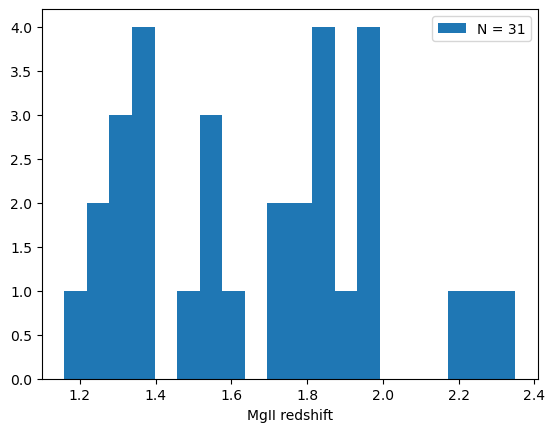

In [16]:
from qsoabsfind.datamodel import AbsorberData
mgii_tab = AbsorberData(f'../data/desi/MgII_cat.fits', autoload=True)
zabs = mgii_tab.catalog["Z_ABS"].data
plt.hist(zabs, bins=20, label = f'N = {zabs.size}')
plt.legend()
plt.xlabel('MgII redshift')

Text(0.5, 0, '$EW_{\\rm MgII}\\, [\\AA]$')

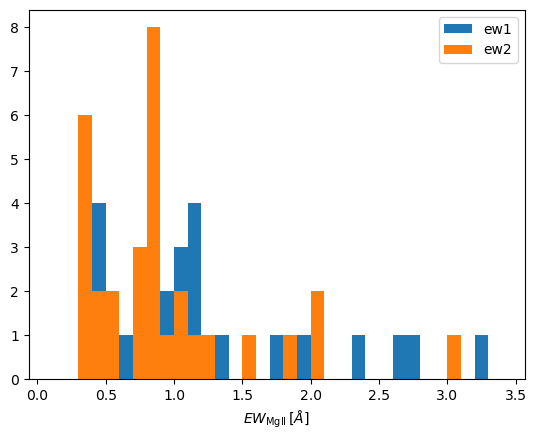

In [17]:
ew1 = mgii_tab.catalog["MGII_2796_EW"].data
ew2 = mgii_tab.catalog["MGII_2803_EW"].data
bins = np.arange(0.1, 3.5, 0.1)
plt.hist(ew1, bins=bins, label='ew1')
plt.hist(ew2, bins=bins, label = 'ew2')
plt.legend()
plt.xlabel(r'$EW_{\rm MgII}\, [\AA]$')

### Plotting spectra

INFO: plotting QSO INDEX = 7...
[INFO] qsoabsfind.datamodel: Time taken to read ../data/desi/qso_test_spectra.fits: 0.02 seconds
[INFO] qsoabsfind.datamodel: Time taken to read ../data/desi/qso_test_spectra.fits: 0.02 seconds
[INFO] qsoabsfind.datamodel: Time taken to read ../data/desi/qso_test_spectra.fits: 0.02 seconds


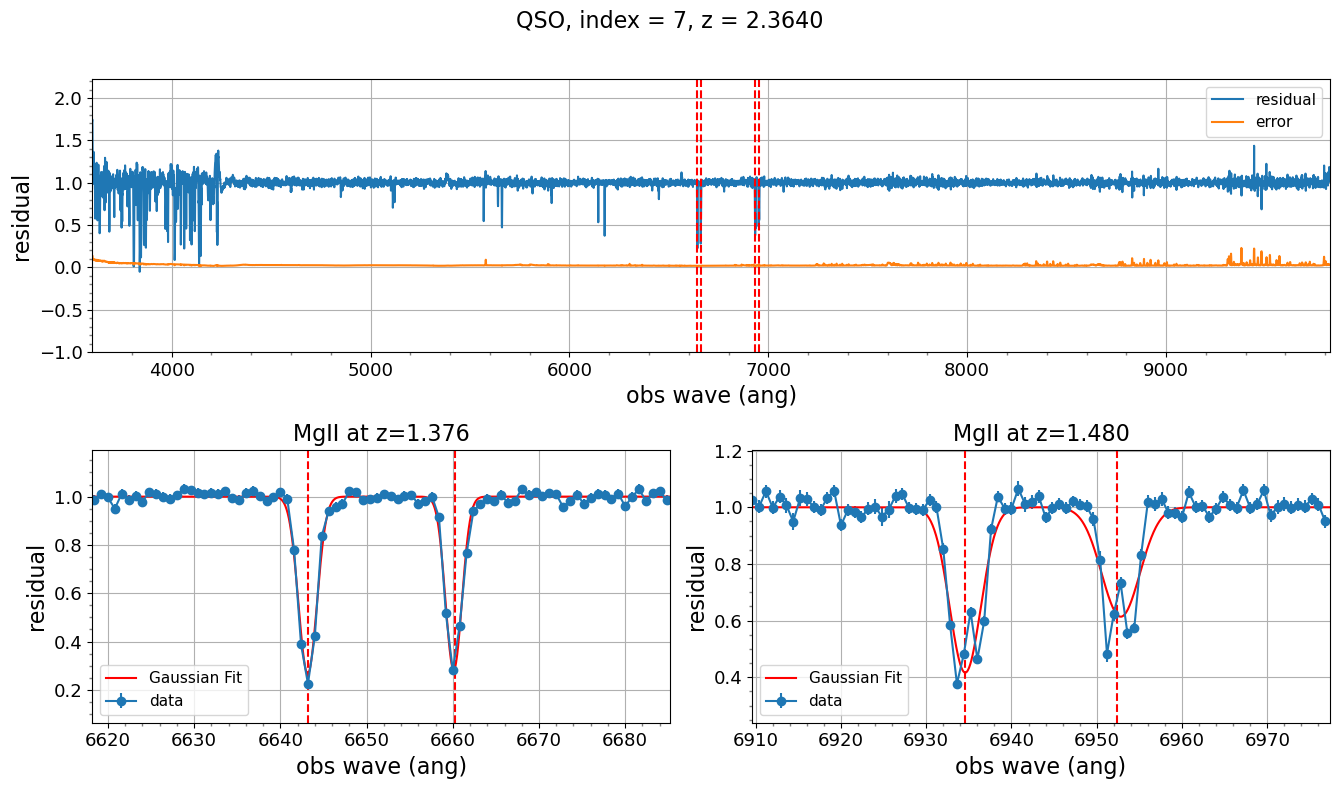

In [18]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.datamodel import QSOSpecRead
import numpy as np

# select a random spectra from MgII_cat.fits
index = mgii_tab.catalog["INDEX_SPEC"].data[1]
print(f'INFO: plotting QSO INDEX = {index}...')
spectra = QSOSpecRead(f'../data/desi/qso_test_spectra.fits', index=index, autoload=True)

# select corresponding zabs table
zabs = mgii_tab.catalog[mgii_tab.catalog["INDEX_SPEC"].data==index]
plot_absorber(spectra, 'MgII', zabs, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index}, z = {spectra.metadata["Z_QSO"]:.4f}', plot_filename=None)

2796.3508084699592 2803.4805254180183 0.449663072344754 0.3989167735863949


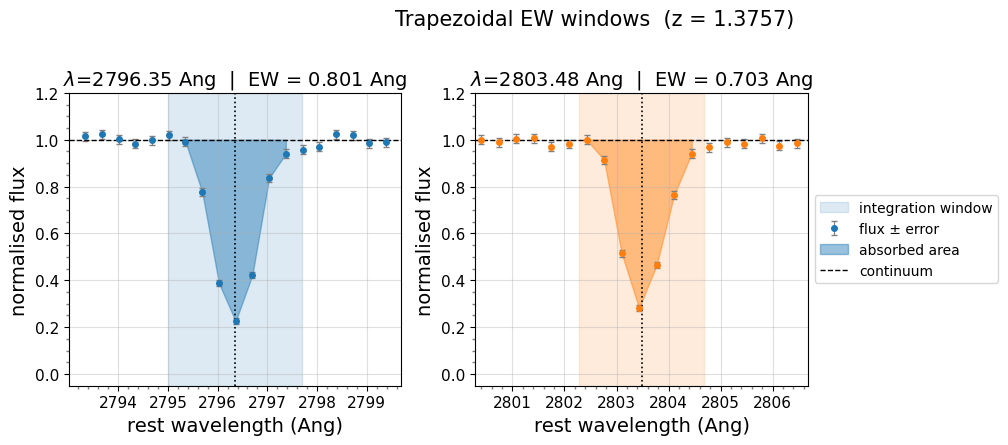

In [19]:
from qsoabsfind.utils import plot_trapezoidal_ew_windows

z = zabs["Z_ABS"][0]
gauss_fit = zabs["GAUSS_FIT"][0]
line1, line2 = gauss_fit[1], gauss_fit[4]
sigma1, sigma2 = gauss_fit[2], gauss_fit[5]

print(line1, line2, sigma1, sigma2)


plot_trapezoidal_ew_windows(
    spectra.wavelength, spectra.flux, spectra.error, z=z,
    line1=line1, line2=line2,
    sigma1=sigma1, sigma2=sigma2,
    n_sigma=3,
)

### Using qsoabsfind internally as module

In [20]:
from qsoabsfind.absfinder import read_single_spectrum_and_find_absorber
from qsoabsfind.config import load_constants

parameters = load_constants(f'../data/desi/desi_constants.py')
read_single_spectrum_and_find_absorber(f'../data/desi/qso_test_spectra.fits', index, 'MgII', **parameters.search_parameters)

{'index_spec': [7, 7],
 'z_abs': [1.375657668236201, 1.4798667102759642],
 'gauss_fit': [[0.7327075626902263,
   2796.3508084683494,
   0.4496630694861026,
   0.7164102588828883,
   2803.48052541669,
   0.39891677362260464],
  [0.5833793344277951,
   2796.3504710621446,
   0.734254405769519,
   0.38619525389810666,
   2803.7050636558192,
   0.901233023307709]],
 'gauss_fit_std': [[0.010542353076528923,
   0.00858895270846834,
   0.009126357567533775,
   0.011591805947329769,
   0.008393560287427515,
   0.008853319938040883],
  [0.010659186820557958,
   0.016350223604812884,
   0.017387500728626923,
   0.011820465073093313,
   0.0347086580665561,
   0.033367283122469546]],
 'ew_1_mean': [0.8258626461029053, 1.0737112760543823],
 'ew_2_mean': [0.7163644433021545, 0.8724367618560791],
 'ew_total_mean': [1.5422271490097046, 1.946148157119751],
 'ew_1_error': [0.07787243276834488, 0.15744706988334656],
 'ew_2_error': [0.06658250838518143, 0.20041318237781525],
 'ew_total_error': [0.10245655

[INFO] qsoabsfind.datamodel: Reading extension 'PRIMARY' (PrimaryHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'PRIMARY' (PrimaryHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'PRIMARY' (PrimaryHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'ABSORBER' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'ABSORBER' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'ABSORBER' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'METADATA' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'METADATA' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'METADATA' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'QSO_INFO' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'QSO_INFO' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'QSO_INFO' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'COLUMN_DENSITY' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'COLUMN_DENSITY' 

Text(0.5, 0, 'CIV redshift')

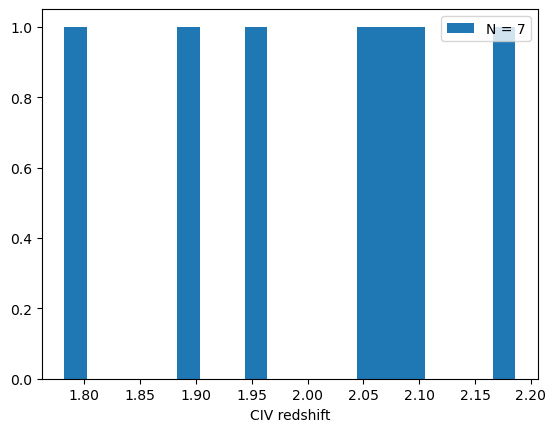

In [21]:
civ_tab = AbsorberData(f'../data/desi/CIV_cat.fits', autoload=True)
civ_zabs = civ_tab.catalog["Z_ABS"].data
plt.hist(civ_zabs, bins=20, label = f'N = {civ_zabs.size}')
plt.legend()
plt.xlabel('CIV redshift')

[INFO] qsoabsfind.datamodel: Time taken to read ../data/desi/qso_test_spectra.fits: 0.02 seconds
[INFO] qsoabsfind.datamodel: Time taken to read ../data/desi/qso_test_spectra.fits: 0.02 seconds
[INFO] qsoabsfind.datamodel: Time taken to read ../data/desi/qso_test_spectra.fits: 0.02 seconds
INFO: plotting CIV for QSO INDEX = 10...


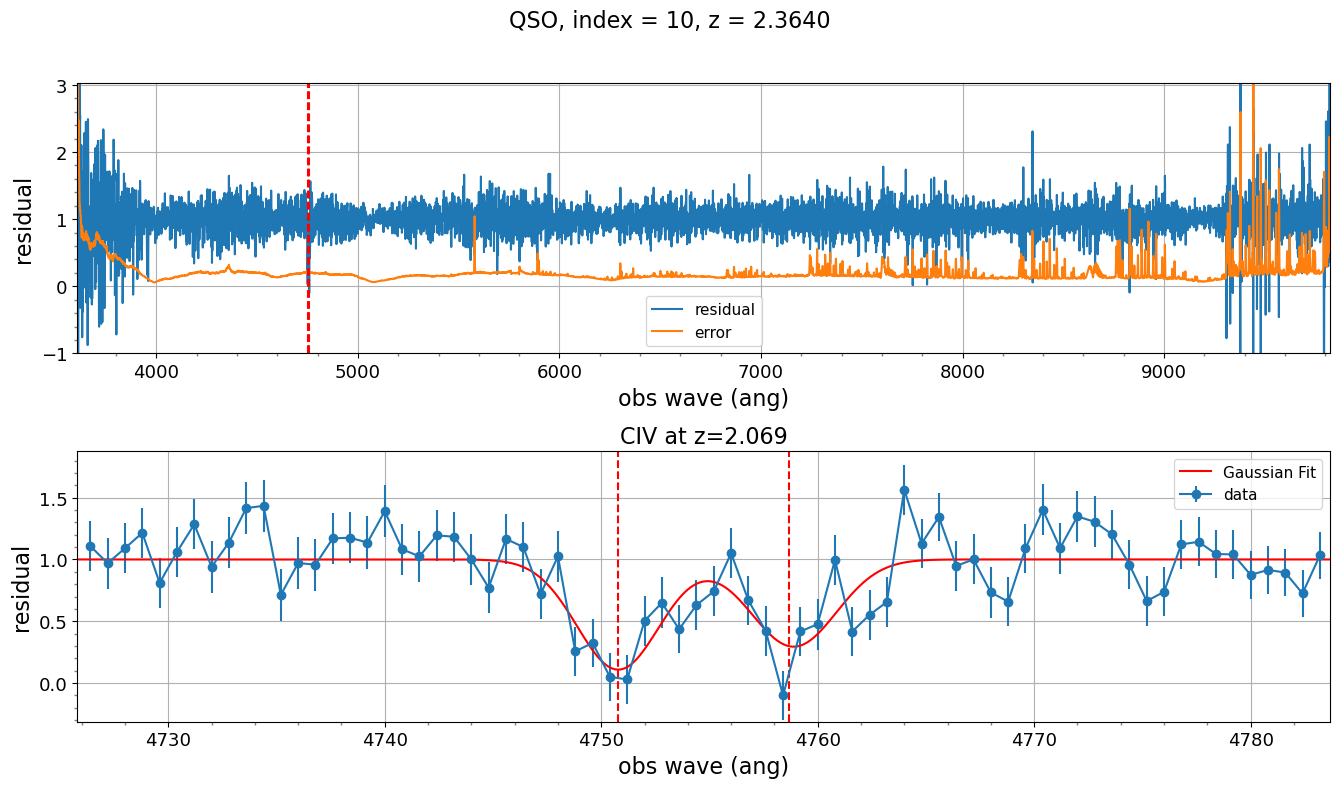

In [22]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.datamodel import QSOSpecRead

# select a random spectra from MgII_cat.fits
index1 = civ_tab.catalog["INDEX_SPEC"].data[0]
spectra1 = QSOSpecRead(f'../data/desi/qso_test_spectra.fits', index=index1, autoload=True)
print(f'INFO: plotting CIV for QSO INDEX = {index1}...')
# select corresponding zabs table
zabs1 = civ_tab.catalog[civ_tab.catalog["INDEX_SPEC"].data==index1]
plot_absorber(spectra1, 'CIV', zabs1, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index1}, z = {spectra.metadata["Z_QSO"]:.4f}', plot_filename=None)

1548.1999420011566 1550.8418979270061 0.6171707572320048 0.643698180619771


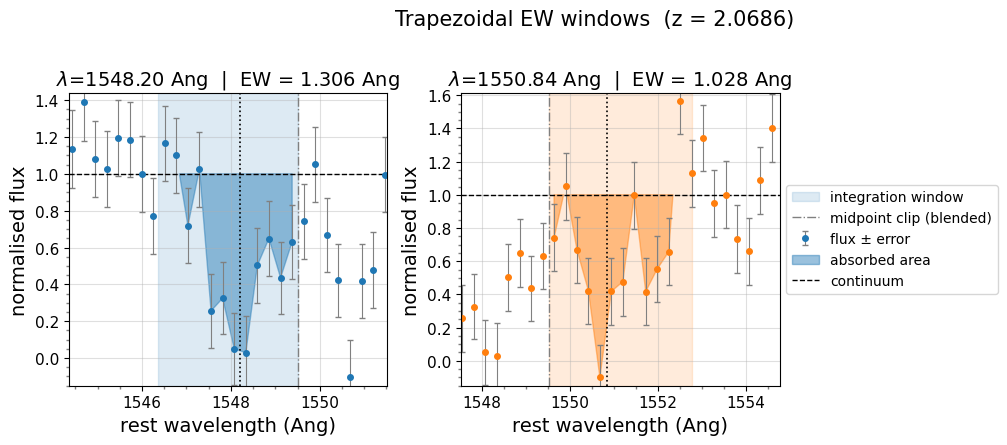

In [23]:
from qsoabsfind.utils import plot_trapezoidal_ew_windows

z1 = zabs1["Z_ABS"][0]
gauss_fit1 = zabs1["GAUSS_FIT"][0]
line1_1, line2_1 = gauss_fit1[1], gauss_fit1[4]
sigma1_1, sigma2_1 = gauss_fit1[2], gauss_fit1[5]

print(line1_1, line2_1, sigma1_1, sigma2_1)


plot_trapezoidal_ew_windows(
    spectra1.wavelength, spectra1.flux, spectra1.error, z=z1,
    line1=line1_1, line2=line2_1,
    sigma1=sigma1_1, sigma2=sigma2_1,
    n_sigma=3,
)